In [1]:
from scipy.integrate import quad
from scipy import integrate
from astropy import units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import warnings
from GtApp import GtApp
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from astropy.table import Table, hstack
import xml.etree.ElementTree as ET
from astropy.coordinates import SkyCoord
import astropy.units as u
from LATSourceModel import SourceList
from scipy.interpolate import interp1d
import warnings
from multiprocessing import Pool
import time
from chainconsumer import ChainConsumer
import emcee



The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
def angle(l, b):
    eccentricity=1
    return np.arccos(np.cos(np.radians(l/eccentricity)) * np.cos(np.radians(b)))
    #Returns angular distance theta in terms of Galactic coordinate system

def wimp_annihilation_map(l, b):
    def NFW(r): #Takes distance from Galactic center
        rho_s = 0.2710150839697834 #GeV/cm^3, Normalization factor, density profile at r=r_0(8.5kpc, Distance from Galactic center and the sun.)
        #Assumes local Dark matter density is 0.4GeV/cm^3
        r_s = 20 #kpc, scale radius for Milky way halo
        gamma = 1.2 #Slope of the profile
        return rho_s*( (r/r_s)**-gamma )/( (1+r/r_s)**(3-gamma) )
        #return value is in dimension of GeV/cm^3
        #Input value is distance from the Galactic center, kpc
    def R(s):#s is line of sight distance >=0, theta is angular separation from the GC
        r_0=8.5 #kpc, distance from the earth and the GC
        theta = angle(l, b)  # Already returns angle in radians
        return np.sqrt(r_0 ** 2 + s ** 2 - 2 * r_0 * s * np.cos(theta))  # Distance from Galactic center    
    
    def rho_squared(s):
        return NFW( R(s) )**2
        
    warnings.filterwarnings("ignore", category=integrate.IntegrationWarning)
    return integrate.quad(rho_squared, 0, np.inf)

## Data preparation part

In [100]:
"""
front='_front'
filters = GtApp('gtselect', 'dataSubselector')
filters['evclass']=256 #CLEAN evclass
filters['evtype']=1 #Front convert
filters['ra']='INDEF'
filters['dec']='INDEF'
filters['rad']='INDEF'
filters['emin']=100
filters['emax']=1000000
filters['zmax']=100
filters['tmin']='INDEF'
filters['tmax']='INDEF'
#filters['tmin']=239557417 #August 4, 2008 00:00
#filters['tmax']=640051200 #April 13, 2021 00:00
filters['infile']='photon_data.txt'
filters['outfile']=f'./GC_analysis/Allsky_select_16yr{front}{"_clean"}.fits'
filters.run()
"""

time -p gtselect infile=photon_data.txt outfile=./GC_analysis/Allsky_select_15yr_front_clean.fits ra="INDEF" dec="INDEF" rad="INDEF" tmin="INDEF" tmax="INDEF" emin=100.0 emax=1000000.0 zmin=0.0 zmax=100.0 evclass=256 evtype=1 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=2 clobber=yes debug=no gui=no mode="ql"
Done.
real 7426.16
user 1743.27
sys 196.15


In [99]:
!cp ./GC_analysis/Allsky_select_16yr_front_clean.fits ./GC_analysis/Allsky_select_16yr_front_clean_legacy.fits

In [107]:
"""
space_craft='./all_sky/lat_spacecraft_merged_16yr.fits'
maketime = GtApp('gtmktime', 'dataSubselector')
maketime['scfile']=space_craft
maketime['filter'] = 'DATA_QUAL==1 && LAT_CONFIG==1 && ABS(ROCK_ANGLE) < 52'
maketime['roicut'] = 'no'
maketime['evfile'] = f'./GC_analysis/Allsky_select_16yr{front}{"_clean"}.fits'
maketime['outfile'] = f'./GC_analysis/Allsky_gti_16yr{front}{"_clean"}.fits'
maketime.run()
"""

time -p gtmktime scfile=./all_sky/lat_spacecraft_merged.fits.2 sctable="SC_DATA" filter="DATA_QUAL==1 && LAT_CONFIG==1 && ABS(ROCK_ANGLE) < 52" roicut=no evfile=./GC_analysis/Allsky_select_15yr_front_clean.fits evtable="EVENTS" outfile="./GC_analysis/Allsky_gti_15yr_front_clean.fits" apply_filter=yes overwrite=no header_obstimes=yes tstart=0.0 tstop=0.0 gtifile="default" chatter=2 clobber=yes debug=no gui=no mode="ql"
real 1097.82
user 849.85
sys 45.80


In [14]:
counts_map = GtApp('gtbin', 'evtbin')
counts_map['algorithm']='CMAP'
counts_map['evfile']=f'./GC_analysis/Allsky_gti_16yr{front}{"_clean"}.fits'
counts_map['outfile']=f'./GC_analysis/GC_cmap_16yr{front}{"_clean"}.fits'
counts_map['nxpix']=600
counts_map['nypix']=600
counts_map['binsz']=0.1
counts_map['coordsys']='GAL'
counts_map['xref']=0
counts_map['yref']=0
counts_map['axisrot']=0
counts_map['proj']='CAR'
counts_map.run()

time -p gtbin evfile=./GC_analysis/Allsky_gti_16yr_front_clean.fits scfile=NONE outfile=./GC_analysis/GC_cmap_16yr_front_clean.fits algorithm="CMAP" ebinalg="FILE" emin=500.0 emax=1000000.0 enumbins=26 denergy=0.0 ebinfile=./GC_analysis/bin_definitions.fits tbinalg="LIN" tstart=0.0 tstop=0.0 dtime=0.0 tbinfile=NONE snratio=0.0 lcemin=0.0 lcemax=0.0 nxpix=600 nypix=600 binsz=0.1 coordsys="GAL" xref=0.0 yref=0.0 axisrot=0.0 rafield="RA" decfield="DEC" proj="CAR" hpx_ordering_scheme="RING" hpx_order=3 hpx_ebin=yes hpx_region="" evtable="EVENTS" sctable="SC_DATA" efield="ENERGY" tfield="TIME" chatter=2 clobber=yes debug=no gui=no mode="ql"
This is gtbin version HEAD
gtbin: WARNING: No spacecraft file: EXPOSURE keyword will be set equal to ontime.
real 78.10
user 63.10
sys 8.04


In [15]:
raw_map=fits.open(f'./GC_analysis/GC_cmap_16yr{front}{"_clean"}.fits')
w=WCS(raw_map[0].header)
# Define the dimensions of the numpy array
width, height = np.shape(raw_map[0].data)

# Create the counts map
wimp_map=np.zeros([width, height])

for i in range(0, height, 1):
    for j in range(0, width, 1):
        l, b = w.wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
        if angle(l, b) < np.radians(120):
            if angle(l, b) < angle(0.05, 0.05):
                wimp_map[i, j] = wimp_annihilation_map(0.05, 0.05)[0]
            else:
                wimp_map[i, j] = wimp_annihilation_map(l, b)[0];
norm = np.sum(wimp_map)*(np.pi/180)**2 * (0.1)**2
wimp_map = wimp_map/norm

Set MJD-END to 60668.079502 from DATE-END'. [astropy.wcs.wcs]


In [163]:
front='_front'
#for i in range(-25, 30, 5):
for i in range(-70, 75, 5):
    if i == 0 or abs(i) < 20:
        continue
    roi=i
    counts_map = GtApp('gtbin', 'evtbin')
    counts_map['algorithm']='CCUBE'
    counts_map['evfile']=f'./GC_analysis/Allsky_gti_16yr{front}{"_clean"}.fits'
    counts_map['outfile']=f'./GC_analysis/GC_ccube_16yr{front}{"_clean"}_l{roi}.fits'
    counts_map['nxpix']=600
    counts_map['nypix']=600
    counts_map['binsz']=0.1
    counts_map['coordsys']='GAL'
    counts_map['xref']=roi
    counts_map['yref']=0
    counts_map['axisrot']=0
    counts_map['proj']='CAR'
    counts_map['ebinalg']='FILE'
    counts_map['ebinfile']='./GC_analysis/bin_definitions.fits'
    counts_map.run()
    
    translated_map=fits.open(f'./GC_analysis/GC_ccube_16yr{front}{"_clean"}_l{roi}.fits').copy()
    del translated_map[1]
    del translated_map[1]
    translated_map[0].data = wimp_map
    translated_map.writeto(f'./FermiLAT/wimp_map_l{roi}.fits', overwrite=True)
    # This part is already done while computing GCE at GC, so will skip it
    

time -p gtbin evfile=./GC_analysis/Allsky_gti_16yr_front_clean.fits scfile=NONE outfile=./GC_analysis/GC_ccube_16yr_front_clean_l-70.fits algorithm="CCUBE" ebinalg="FILE" emin=30.0 emax=200000.0 enumbins=0 denergy=0.0 ebinfile=./GC_analysis/bin_definitions.fits tbinalg="LIN" tstart=0.0 tstop=0.0 dtime=0.0 tbinfile=NONE snratio=0.0 lcemin=0.0 lcemax=0.0 nxpix=600 nypix=600 binsz=0.1 coordsys="GAL" xref=-70.0 yref=0.0 axisrot=0.0 rafield="RA" decfield="DEC" proj="CAR" hpx_ordering_scheme="RING" hpx_order=3 hpx_ebin=yes hpx_region="" evtable="EVENTS" sctable="SC_DATA" efield="ENERGY" tfield="TIME" chatter=2 clobber=yes debug=no gui=no mode="ql"
This is gtbin version HEAD
gtbin: WARNING: No spacecraft file: EXPOSURE keyword will be set equal to ontime.
real 83.68
user 80.06
sys 3.41
time -p gtbin evfile=./GC_analysis/Allsky_gti_16yr_front_clean.fits scfile=NONE outfile=./GC_analysis/GC_ccube_16yr_front_clean_l-65.fits algorithm="CCUBE" ebinalg="FILE" emin=30.0 emax=200000.0 enumbins=0 dene

In [111]:
"""
ltCube = GtApp('gtltcube', 'Likelihood')
ltCube['evfile']=f'./GC_analysis/Allsky_gti_16yr{front}{"_clean"}.fits'
ltCube['scfile']='./all_sky/lat_spacecraft_merged_16yr.fits'
ltCube['outfile']=f'./GC_analysis/Allsky_ltcube_16yr{front}{"_clean"}.fits'
ltCube['dcostheta']=0.025
ltCube['binsz']=1
ltCube['zmax']=100
ltCube.run()
"""

time -p gtltcube evfile="./GC_analysis/Allsky_gti_15yr_front_clean.fits" evtable="EVENTS" scfile=./all_sky/lat_spacecraft_merged.fits.2 sctable="SC_DATA" outfile=./GC_analysis/Allsky_ltcube_15yr_front_clean.fits dcostheta=0.025 binsz=1.0 phibins=0 tmin=0.0 tmax=0.0 file_version="1" zmin=0.0 zmax=100.0 chatter=2 clobber=yes debug=no gui=no mode="ql"
Working on file ./all_sky/lat_spacecraft_merged.fits.2
.....................!
real 8662.81
user 8637.07
sys 10.29


In [165]:
#for i in range(-25, 30, 5):
for i in range(-70, 75, 5):
    if i == 0 or abs(i) < 20:
        continue
    roi=i    
    gtexpcube2 = GtApp('gtexpcube2', 'Likelihood')
    gtexpcube2['infile']=f'./GC_analysis/Allsky_ltcube_16yr{front}{"_clean"}.fits'
    gtexpcube2['cmap']='none'
    gtexpcube2['outfile']=f'./GC_analysis/GC_expcube_center_16yr{front}{"_clean"}_l{roi}.fits'
    gtexpcube2['evtype']=1
    gtexpcube2['coordsys']='GAL'
    gtexpcube2['xref']=roi
    gtexpcube2['yref']=0
    gtexpcube2['nxpix']=600
    gtexpcube2['nypix']=600
    gtexpcube2['proj']='CAR'
    gtexpcube2['binsz']=0.1
    gtexpcube2['bincalc']='CENTER'
    gtexpcube2['irfs']='P8R3_CLEAN_V3'
    gtexpcube2['ebinalg']='FILE'
    gtexpcube2['ebinfile']='./GC_analysis/bin_definitions.fits'
    gtexpcube2.run()

time -p gtexpcube2 infile=./GC_analysis/Allsky_ltcube_16yr_front_clean.fits cmap=none outfile=./GC_analysis/GC_expcube_center_16yr_front_clean_l-70.fits irfs="P8R3_CLEAN_V3" evtype=1 edisp_bins=0 nxpix=600 nypix=600 binsz=0.1 coordsys="GAL" xref=-70.0 yref=0.0 axisrot=0.0 proj="CAR" ebinalg="FILE" emin="INDEF" emax="INDEF" enumbins="INDEF" ebinfile="./GC_analysis/bin_definitions.fits" hpx_ordering_scheme="RING" hpx_order=6 bincalc="CENTER" ignorephi=no thmax=180.0 thmin=0.0 table="EXPOSURE" chatter=2 clobber=yes debug=no mode="ql"
Computing binned exposure map....................!
real 9.28
user 9.22
sys 3.34
time -p gtexpcube2 infile=./GC_analysis/Allsky_ltcube_16yr_front_clean.fits cmap=none outfile=./GC_analysis/GC_expcube_center_16yr_front_clean_l-65.fits irfs="P8R3_CLEAN_V3" evtype=1 edisp_bins=0 nxpix=600 nypix=600 binsz=0.1 coordsys="GAL" xref=-65.0 yref=0.0 axisrot=0.0 proj="CAR" ebinalg="FILE" emin="INDEF" emax="INDEF" enumbins="INDEF" ebinfile="./GC_analysis/bin_definitions.f

In [166]:
gtexpcube2 = GtApp('gtexpcube2', 'Likelihood')
gtexpcube2['infile']=f'./GC_analysis/Allsky_ltcube_16yr{front}{"_clean"}.fits'
gtexpcube2['cmap']='none'
gtexpcube2['outfile']=f'./GC_analysis/Allsky_expcube_edge_16yr{front}{"_clean"}.fits'
gtexpcube2['evtype']=1
gtexpcube2['coordsys']='GAL'
gtexpcube2['xref']=0
gtexpcube2['yref']=0
gtexpcube2['nxpix']=3600
gtexpcube2['nypix']=1800
gtexpcube2['proj']='CAR'
gtexpcube2['binsz']=0.1
gtexpcube2['bincalc']='EDGE'
gtexpcube2['irfs']='P8R3_CLEAN_V3'
gtexpcube2['ebinalg']='FILE'
gtexpcube2['ebinfile']='./GC_analysis/bin_definitions.fits'
gtexpcube2.run()

time -p gtexpcube2 infile=./GC_analysis/Allsky_ltcube_16yr_front_clean.fits cmap=none outfile=./GC_analysis/Allsky_expcube_edge_16yr_front_clean.fits irfs="P8R3_CLEAN_V3" evtype=1 edisp_bins=0 nxpix=3600 nypix=1800 binsz=0.1 coordsys="GAL" xref=0.0 yref=0.0 axisrot=0.0 proj="CAR" ebinalg="FILE" emin="INDEF" emax="INDEF" enumbins="INDEF" ebinfile="./GC_analysis/bin_definitions.fits" hpx_ordering_scheme="RING" hpx_order=6 bincalc="EDGE" ignorephi=no thmax=180.0 thmin=0.0 table="EXPOSURE" chatter=2 clobber=yes debug=no mode="ql"
Computing binned exposure map....................!
real 166.59
user 156.49
sys 4.34


In [3]:
def galactic_to_equatorial(l, b):
    # Create a SkyCoord object with Galactic coordinates
    galactic_coord = SkyCoord(l=l*u.degree, b=b*u.degree, frame='galactic')

    # Convert to J2000 equatorial coordinates
    equatorial_coord = galactic_coord.icrs

    # Extract RA and Dec
    ra = equatorial_coord.ra.degree
    dec = equatorial_coord.dec.degree

    return ra, dec

def equatorial_to_galactic(ra, dec):
    # Create a SkyCoord object with equatorial coordinates (J2000)
    equatorial_coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')

    # Convert to Galactic coordinates
    galactic_coord = equatorial_coord.galactic

    # Extract l and b
    l = galactic_coord.l.degree
    b = galactic_coord.b.degree

    return l, b

def is_within_roi(l, b):
    """
    Check if the coordinates (l, b) are within the 60x60 degree region centered at the Galactic Center,
    accounting for longitude wrapping (-20 and 340 degrees are equivalent).
    
    Parameters:
    l (float): Galactic longitude in degrees (can be negative or greater than 360)
    b (float): Galactic latitude in degrees
    
    Returns:
    bool: True if the coordinates are within the region, False otherwise
    """
    # Normalize l to be in the range [-180, 180]
    if l > 180:
        l -= 360
    
    # Check if the coordinates are within the 60x60 degree region
    return abs(b) <= 40 and abs(l) <= 40


def masking(significance, locations, energy, image_file): #Input GeV, location ra dec, radius theta
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", message="'datfix' made the change")

    data = [
    [0.275, 0.357, 1.125, 3.75],
    [0.357, 0.464, 0.975, 3.25],
    [0.464, 0.603, 0.788, 2.63],
    [0.603, 0.784, 0.600, 2.00],
    [0.784, 1.02, 0.450, 1.50],
    [1.02, 1.32, 0.375, 1.25],
    [1.32, 1.72, 0.300, 1.00],
    [1.72, 2.24, 0.225, 0.750],
    [2.24, 2.91, 0.188, 0.625],
    [2.91, 3.78, 0.162, 0.540],
    [3.78, 4.91, 0.125, 0.417],
    [4.91, 10.8, 0.100, 0.333],
    [10.8, 23.7, 0.060, 0.200],
    [23.7, 51.9, 0.053, 0.175]] #Mask definition is taken from 2112.09706v2, Table III
    data=np.asarray(data)
    
    mask_energy=np.sqrt(data[0:, 0]*data[0:, 1])
    mask_small=data[0:, 2]
    mask_large=data[0:, 3]
    

    mask_small_int=interp1d(mask_energy, mask_small, fill_value='extrapolate')
    mask_large_int=interp1d(mask_energy, mask_large, fill_value='extrapolate')
    
    
    mask_small_size=(mask_small_int(energy))
    mask_large_size=(mask_large_int(energy))

    mask_small_size[mask_small_size<=0] = 0
    mask_large_size[mask_large_size<=0] = 0

    mask_small_size = mask_small_size
    mask_large_size = mask_large_size
    
    #print(energy, mask_small_size, mask_large_size)

    fits_file = image_file
    hdulist = fits.open(fits_file)
    data = hdulist[0].data[0]  # Assuming the image data is in the first extension
    header = hdulist[0].header

    masked_data = np.ones(np.shape(data))
    # Get WCS information from the header
    wcs = WCS(header).dropaxis(2)
    
    for points in locations:
        #print(points[0])
        l, b = equatorial_to_galactic(float(points[1]), float(points[2]))
        #print(l, b)
        # Define your point of interest in Galactic coordinates
        # Convert Galactic coordinates to Equatorial coordinates (RA, Dec)
        galactic_coords = SkyCoord(l=l*u.degree, b=b*u.degree, frame='galactic')
        # Convert Equatorial coordinates to pixel coordinates
        pixel_coords = wcs.world_to_pixel(galactic_coords)
        # Extract pixel coordinates
        x_center = np.round(pixel_coords[0], 0)
        y_center = np.round(pixel_coords[1], 0)

        #print(f"Pixel Coordinates: x = {x_center}, y = {y_center}")

        # Calculate the pixel scale (degree per pixel)
        #if wcs.wcs.has_cd():
        #    cd = wcs.wcs.cd
        #    pixel_scale_x = np.sqrt(cd[0, 0]**2 + cd[1, 0]**2)
        #    pixel_scale_y = np.sqrt(cd[0, 1]**2 + cd[1, 1]**2)
        #else:
        #    pixel_scale_x = wcs.wcs.cdelt[0]
        #    pixel_scale_y = wcs.wcs.cdelt[1]
        pixel_scale_x = wcs.wcs.cdelt[0]
        pixel_scale_y = wcs.wcs.cdelt[1]

        # Calculate the radius in pixels corresponding to 1 degree
        if significance==1:
            radius_deg = mask_large_size
        if significance==0:
            radius_deg = mask_small_size
        
        radius_pix_x = radius_deg / pixel_scale_x
        radius_pix_y = radius_deg / pixel_scale_y
        radius_pix = min(radius_pix_x, radius_pix_y)
        if abs(radius_pix_x) != abs(radius_pix_y):
            print(radius_pix_x, radius_pix_y)
        
        #print(f"Radius in pixels: {radius_pix}, Radius in degree : {radius_deg}")

        # Create a circular mask
        y, x = np.ogrid[:data.shape[0], :data.shape[1]]
        mask = (x - x_center)**2 + (y - y_center)**2 < radius_pix**2
        
        #y, x = np.ogrid[:data.shape[0], :data.shape[1]]
        #distance_from_center = np.sqrt((x - x_center)**2 + (y - y_center)**2)
        #mask = distance_from_center <= radius_pix
        
        # Apply the mask to the image data
        masked_data[mask] = 0  # Set the masked region to NaN (or any other value that represents masking)

        #plt.imshow(masked_data, cmap='jet')
    
    return masked_data


In [168]:
E

array([3.13328902e-01, 4.06998780e-01, 5.28953677e-01, 6.87569631e-01,
       8.94248272e-01, 1.16034479e+00, 1.50678468e+00, 1.96285509e+00,
       2.55311571e+00, 3.31659468e+00, 4.30810856e+00, 7.28203256e+00,
       1.60176404e+01, 3.52324044e+01, 7.74964412e+01, 1.70459967e+02,
       3.74941680e+02])

In [4]:
def mask_creation(roi):
    RA, DEC = galactic_to_equatorial(roi, 0)
    source_list=SourceList(DR=4, catalog_file='./GC_analysis/gll_psc_v32.xml', ROI=[RA, DEC, 35], output_name=f'GC_model_DR4_l{roi}.xml', write_directory='./GC_analysis/Model/')
    source_list.make_model(extended_catalog_names=True, norms_free_only=True, galactic_index_free=True, extra_radius=5, free_radius=28.28, max_free_radius=28.28 , variable_free=True,sigma_to_free=49, galactic_name='gll_iem', galactic_file='../gll_iem_v07.fits', isotropic_file='../iso_P8R3_SOURCE_V3_v1.txt', isotropic_name='isotropic', extended_directory='/home/sanghwan/FermiLAT/Sanghwan/Extended_14years/Templates/')

    tree = ET.parse(f'./GC_analysis/Model/GC_model_DR4_l{roi}.xml')
    root = tree.getroot()
    
    # Find and remove the elements
    for source in root.findall(".//source"):
        if 'isotropic' in source.get('name', ''):
            root.remove(source)
        if 'gll_iem' in source.get('name', ''):
            root.remove(source)
    # Save the modified XML to a new file
    tree.write(f'./GC_analysis/Model/GC_psc_model_DR4_l{roi}.xml', encoding='utf-8', xml_declaration=True)
    
    ra_dec_values = []
    spatial_ra_dec_values = []
    tree = ET.parse(f'./GC_analysis/Model/GC_psc_model_DR4_l{roi}.xml')
    root = tree.getroot()
    
    # Find and remove the elements
    for source in root.findall(".//source"):
        source_name = source.attrib.get('name', '')
        source_type = source.attrib.get('type', '')
        if source_type=='PointSource':
            #for param in source.findall(".//spectrum/parameter"):
            ra = float(source.find(".//spatialModel/parameter[@name='RA']").attrib['value'])
            dec = float(source.find(".//spatialModel/parameter[@name='DEC']").attrib['value'])
            l, b = equatorial_to_galactic(ra, dec)
            if True:#is_within_roi(l, b):
                #name = source.attrib['name']
                ra_dec_values.append([source_name, ra, dec])
            #else:
                #print(source_name, l, b)
        if source_type == "DiffuseSource":
            spatial_model = source.find(".//spatialModel")
            if spatial_model is not None:# and source.attrib['type']=='SpatialMap':
                if spatial_model.attrib.get('type') == 'SpatialMap':
                    file_path = spatial_model.attrib.get('file')
                    if file_path:
                        ra = fits.open(file_path)[0].header['CRVAL1']
                        dec = fits.open(file_path)[0].header['CRVAL2']
                        l, b = equatorial_to_galactic(ra, dec)
                        if True:#is_within_roi(l, b):
                            spatial_ra_dec_values.append([source_name, ra, dec])
                if spatial_model.attrib.get('type') != 'SpatialMap':
                    ra = float(source.find(".//spatialModel/parameter[@name='RA']").attrib['value'])
                    dec = float(source.find(".//spatialModel/parameter[@name='DEC']").attrib['value'])
                    l, b = equatorial_to_galactic(ra, dec)
                    if True:#is_within_roi(l, b):
                    #spatial_ra_dec_values.append([source_name, ra, dec])
                    #ra_dec_values.append([source_name, ra, dec])
                        spatial_ra_dec_values.append([source_name, ra, dec])

    not_sig_ra_dec_values = ra_dec_values + spatial_ra_dec_values
    sig_ra_dec_values=[]
    data=fits.open('./GC_analysis/gll_psc_v35.fit')[1].data
    for row in data:
        for lists in not_sig_ra_dec_values:
            if row['Source_Name'] == lists[0]:
                if row['Signif_Avg'] > 49:
                    sig_ra_dec_values.append(lists)
                    not_sig_ra_dec_values.remove(lists)
                    #print(row['Source_Name'], row['Signif_Avg'], lists)
                    
    file_name=f'./GC_analysis/GC_ccube_16yr{front}{"_clean"}_l{roi}.fits'
    
    E_bounds=fits.open(file_name)[1].data
    E=np.zeros(len(E_bounds))
    for i in range(len(E_bounds)):
        E[i] = 1e-3*np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)#Into GeV

    raw_data_map=fits.open(file_name)[0].data
    mask_big=np.zeros(np.shape(raw_data_map))
    mask_small=np.zeros(np.shape(raw_data_map))
    mask_big_spatial=np.zeros(np.shape(raw_data_map))
    mask_small_spatial=np.zeros(np.shape(raw_data_map))
    
    for i in range(0, len(mask_big), 1):
        mask_big[i] = masking(1, sig_ra_dec_values, E[i], file_name)
        mask_small[i] = masking(0, not_sig_ra_dec_values, E[i], file_name)
    
    full_mask=mask_big*mask_small

    np.save(f'./GC_analysis/Model/GC_mask_60x60_definitions_DR4_l{roi}.npy', full_mask)
    print(f'{roi} creation done')

for i in range(-70, 75, 5):
#for i in range(60, 75, 5):
    if i == 0 or abs(i) < 20:
        continue
    print(i)
    mask_creation(i)

-70
Creating spatial and spectral model from the 4FGL DR-4 catalog: GC_analysis/gll_psc_v32.xml.


/home/sanghwan/.conda/envs/fermipy/lib/python3.9/site-packages/LATSourceModel/SourceList.py:153: UserWarning: Region XML model GC_analysis/Model/GC_model_DR4_l-70.xml already exists, will be overwritten if you call the make_model method.
  warnings.warn(f'Region XML model {str(self.output_name)} already exists, will be\
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1519b6ea8ee0>>
Traceback (most recent call last):
  File "/home/sanghwan/.conda/envs/fermipy/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1519b6ea8ee0>>
Traceback (most recent call last):
  File "/home/sanghwan/.conda/envs/fermipy/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_fra

KeyboardInterrupt: 

In [5]:
# --------------------------------------------

In [23]:
def mask_creation(roi):
    RA, DEC = galactic_to_equatorial(roi, 0)
    source_list=SourceList(DR=4, catalog_file='./GC_analysis/gll_psc_v32.xml', ROI=[RA, DEC, 35], output_name=f'GC_model_DR4_l{roi}.xml', write_directory='./GC_analysis/Model/')
    source_list.make_model(extended_catalog_names=True, norms_free_only=True, galactic_index_free=True, extra_radius=5, free_radius=28.28, max_free_radius=28.28 , variable_free=True,sigma_to_free=49, galactic_name='gll_iem', galactic_file='../gll_iem_v07.fits', isotropic_file='../iso_P8R3_SOURCE_V3_v1.txt', isotropic_name='isotropic', extended_directory='/home/sanghwan/FermiLAT/Sanghwan/Extended_14years/Templates/')

    tree = ET.parse(f'./GC_analysis/Model/GC_model_DR4_l{roi}.xml')
    root = tree.getroot()
    
    # Find and remove the elements
    for source in root.findall(".//source"):
        if 'isotropic' in source.get('name', ''):
            root.remove(source)
        if 'gll_iem' in source.get('name', ''):
            root.remove(source)
    # Save the modified XML to a new file
    tree.write(f'./GC_analysis/Model/GC_psc_model_DR4_l{roi}.xml', encoding='utf-8', xml_declaration=True)
    
    ra_dec_values = []
    spatial_ra_dec_values = []
    # tree = ET.parse(f'./GC_analysis/Model/GC_psc_model_DR4_l{roi}.xml')
    tree = ET.parse('./GC_analysis/Model/GC_psc_model_DR4.xml')

    root = tree.getroot()
    
    # Find and remove the elements
    for source in root.findall(".//source"):
        source_name = source.attrib.get('name', '')
        source_type = source.attrib.get('type', '')
        if source_type=='PointSource':
            #for param in source.findall(".//spectrum/parameter"):
            ra = float(source.find(".//spatialModel/parameter[@name='RA']").attrib['value'])
            dec = float(source.find(".//spatialModel/parameter[@name='DEC']").attrib['value'])
            l, b = equatorial_to_galactic(ra, dec)
            if True:#is_within_roi(l, b):
                #name = source.attrib['name']
                ra_dec_values.append([source_name, ra, dec])
            #else:
                #print(source_name, l, b)
        if source_type == "DiffuseSource":
            spatial_model = source.find(".//spatialModel")
            if spatial_model is not None:# and source.attrib['type']=='SpatialMap':
                if spatial_model.attrib.get('type') == 'SpatialMap':
                    file_path = spatial_model.attrib.get('file')
                    if file_path:
                        ra = fits.open(file_path)[0].header['CRVAL1']
                        dec = fits.open(file_path)[0].header['CRVAL2']
                        l, b = equatorial_to_galactic(ra, dec)
                        if True:#is_within_roi(l, b):
                            spatial_ra_dec_values.append([source_name, ra, dec])
                if spatial_model.attrib.get('type') != 'SpatialMap':
                    ra = float(source.find(".//spatialModel/parameter[@name='RA']").attrib['value'])
                    dec = float(source.find(".//spatialModel/parameter[@name='DEC']").attrib['value'])
                    l, b = equatorial_to_galactic(ra, dec)
                    if True:#is_within_roi(l, b):
                    #spatial_ra_dec_values.append([source_name, ra, dec])
                    #ra_dec_values.append([source_name, ra, dec])
                        spatial_ra_dec_values.append([source_name, ra, dec])

    not_sig_ra_dec_values = ra_dec_values + spatial_ra_dec_values
    sig_ra_dec_values=[]
    print(len(ra_dec_values) + len(spatial_ra_dec_values))
    data=fits.open('./GC_analysis/gll_psc_v35.fit')[1].data
    for row in data:
        for lists in not_sig_ra_dec_values:
            if row['Source_Name'] == lists[0]:
                if row['Signif_Avg'] > 49:
                    sig_ra_dec_values.append(lists)
                    not_sig_ra_dec_values.remove(lists)
                    #print(row['Source_Name'], row['Signif_Avg'], lists)
                    
    file_name=f'./GC_analysis/GC_ccube_16yr{front}{"_clean"}.fits'
    
    E_bounds=fits.open(file_name)[1].data
    E=np.zeros(len(E_bounds))
    for i in range(len(E_bounds)):
        E[i] = 1e-3*np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)#Into GeV

    raw_data_map=fits.open(file_name)[0].data
    mask_big=np.zeros(np.shape(raw_data_map))
    mask_small=np.zeros(np.shape(raw_data_map))
    mask_big_spatial=np.zeros(np.shape(raw_data_map))
    mask_small_spatial=np.zeros(np.shape(raw_data_map))
    
    for i in range(0, len(mask_big), 1):
        mask_big[i] = masking(1, sig_ra_dec_values, E[i], file_name)
        mask_small[i] = masking(0, not_sig_ra_dec_values, E[i], file_name)
    
    full_mask=mask_big*mask_small

    np.save(f'./GC_analysis/Model/GC_mask_60x60_definitions_DR4_l{roi}.npy', full_mask)
    print(f'{roi} creation done')
front='_front'
mask_creation(0)

/home/sanghwan/.conda/envs/fermipy/lib/python3.9/site-packages/LATSourceModel/SourceList.py:153: UserWarning: Region XML model GC_analysis/Model/GC_model_DR4_l0.xml already exists, will be overwritten if you call the make_model method.
  warnings.warn(f'Region XML model {str(self.output_name)} already exists, will be\


Creating spatial and spectral model from the 4FGL DR-4 catalog: GC_analysis/gll_psc_v32.xml.
Extended source 4FGL J1713.5-3945e in model, make sure that the following path to extended template is correct: /home/sanghwan/FermiLAT/Sanghwan/Extended_14years/Templates/RXJ1713_2016_250GeV.fits
Extended source 4FGL J1840.9-0532e in model, make sure that the following path to extended template is correct: /home/sanghwan/FermiLAT/Sanghwan/Extended_14years/Templates/HESSJ1841-055.fits
Extended source 4FGL J1552.9-5607e in model, make sure that the following path to extended template is correct: /home/sanghwan/FermiLAT/Sanghwan/Extended_14years/Templates/MSH15-56_SNRmask.fits
Extended source 4FGL J1552.4-5612e in model, make sure that the following path to extended template is correct: /home/sanghwan/FermiLAT/Sanghwan/Extended_14years/Templates/MSH15-56_PWN.fits
Extended source 4FGL J1855.9+0121e in model, make sure that the following path to extended template is correct: /home/sanghwan/FermiLAT

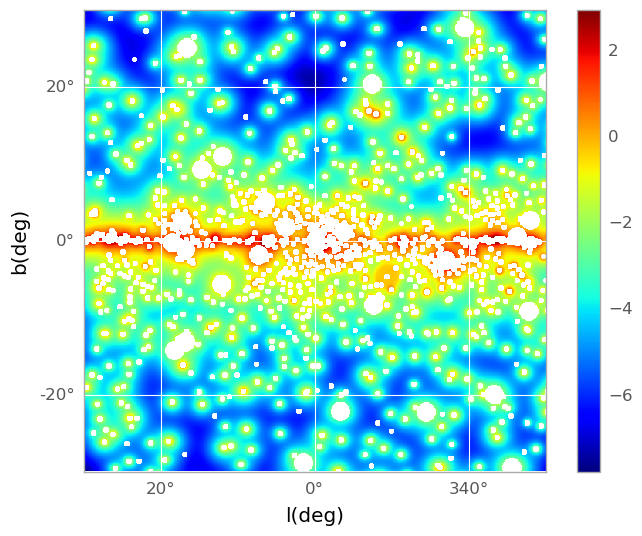

In [21]:
src=fits.open('./GC_analysis/GC_psc_model_16yr_front_clean.fits')
w=WCS(src[0].header)

fig=plt.figure()
ax=fig.add_subplot(111,projection=w.dropaxis(2))
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True) #Changing coordinate tick label into decimal.
#ax.coords.grid(False)
ax.coords['glon'].grid(color='none')
ax.coords['glat'].grid(color='none')

plot=ax.imshow( np.log(src[0].data[5]*full_mask[5]), origin='lower', cmap='jet', interpolation='nearest')
plt.grid(color='white', ls='solid')
#plt.axis('off')
#plt.grid(False)
plt.xlabel('l(deg)')
plt.ylabel('b(deg)')
plt.colorbar(plot)


In [6]:
# --------------------------------------------

In [16]:
#This part is also done previously by GCE at GC notebook. Can skip.

model='X'
#for i in range(-25, 30, 5):
for i in range(-70, 75, 5):
    if i == 0 or abs(i) < 20:
        continue
    roi=i
    # Define the elements to add
    new_sources = f"""
    <source name="bremss" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/bremss_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="ics" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.04073673429" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/ics_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="pion" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/pion_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="GCE" type="DiffuseSource">
        <spectrum type="BrokenPowerLaw">
        <parameter free="0" max="1000.0" min="0.001" name="Prefactor" scale="1e-04" value="7*3.6276211633314497"/>
        <parameter free="0" max="-1.0" min="-5." name="Index1" scale="1.0" value="-1.42"/>
        <parameter free="0" max="3000.0" min="30.0" name="BreakValue" scale="1.0" value="2006"/>
        <parameter free="0" max="-1.0" min="-5." name="Index2" scale="1.0" value="-2.63"/>
    </spectrum>
        <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/wimp_map_l{roi}.fits" type="SpatialMap" map_based_integral="true">
        </spatialModel>
      </source>
      <source name="isotropic" type="DiffuseSource">
        <spectrum apply_edisp="true" file="/home/sanghwan/FermiLAT/Sanghwan/GC_14yr/data/Model/isotropic_spectrum.txt" type="FileFunction">
          <parameter free="1" max="10" min="1" name="Normalization" scale="1" value="1" />
        </spectrum>
        <spatialModel type="ConstantValue">
          <parameter free="0" max="10" min="0" name="Value" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="Fermi_bubble" type="DiffuseSource">
        <spectrum apply_edisp="true" file="/home/sanghwan/FermiLAT/Sanghwan/GC_14yr/data/Model/fermi_bubble_spectrum.txt" type="FileFunction">
          <parameter free="1" max="1e+10" min="0" name="Normalization" scale="1e-3" value="5" />
        </spectrum>
        <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Fermi_bubble_template.fits" type="SpatialMap" map_based_integral="true">
        </spatialModel>
      </source>
    """
    

    new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
    new_sources_root = new_sources_tree.getroot()
    
    # Parse the existing XML file
    tree = ET.parse('./GC_analysis/Model/empty_model.xml')
    root = tree.getroot()
    
    for new_source in new_sources_root:
        root.append(new_source)
    
    tree.write(f'./GC_analysis/Model/GC_Extended_model{model}_l{roi}.xml', encoding='utf-8', xml_declaration=True)


    new_sources = f"""
      <source name="GCE" type="DiffuseSource">
        <spectrum type="BrokenPowerLaw">
        <parameter free="0" max="1000.0" min="0.001" name="Prefactor" scale="1e-12" value="3"/>
        <parameter free="0" max="-1.0" min="-5." name="Index1" scale="1.0" value="-1.42"/>
        <parameter free="0" max="3000.0" min="30.0" name="BreakValue" scale="1.0" value="2006"/>
        <parameter free="0" max="-1.0" min="-5." name="Index2" scale="1.0" value="-2.63"/>
    </spectrum>
        <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/wimp_map_l{roi}.fits" type="SpatialMap" map_based_integral="true">
        </spatialModel>
      </source>
    """
    
    # Parse the new sources XML string
    new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
    new_sources_root = new_sources_tree.getroot()
    
    # Parse the existing XML file
    tree = ET.parse('./GC_analysis/Model/empty_model.xml')
    root = tree.getroot()
    
    # Append the new sources to the root element of the existing file
    for new_source in new_sources_root:
        root.append(new_source)
    
    # Save the modified XML to a new file
    tree.write(f'./GC_analysis/Model/GC_GCE_model_l{roi}.xml', encoding='utf-8', xml_declaration=True)


    new_sources = f"""
      <source name="GCE" type="DiffuseSource">
        <spectrum type="BrokenPowerLaw">
        <parameter free="0" max="1000.0" min="0.001" name="Prefactor" scale="1e-12" value="3"/>
        <parameter free="0" max="-1.0" min="-5." name="Index1" scale="1.0" value="-1.42"/>
        <parameter free="0" max="3000.0" min="30.0" name="BreakValue" scale="1.0" value="2006"/>
        <parameter free="0" max="-1.0" min="-5." name="Index2" scale="1.0" value="-2.63"/>
    </spectrum>
        <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/wimp_map_l{roi}.fits" type="SpatialMap" map_based_integral="true">
        </spatialModel>
      </source>
    """
    
    # Parse the new sources XML string
    new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
    new_sources_root = new_sources_tree.getroot()
    
    # Parse the existing XML file
    tree = ET.parse('./GC_analysis/Model/empty_model.xml')
    root = tree.getroot()
    
    # Append the new sources to the root element of the existing file
    for new_source in new_sources_root:
        root.append(new_source)
    
    # Save the modified XML to a new file
    tree.write(f'./GC_analysis/Model/GC_GCE_model_l{roi}.xml', encoding='utf-8', xml_declaration=True)



In [18]:
#for i in range(-25, 30, 5):
for i in range(-70, 75, 5):
    if i == 0 or abs(i) < 20:
        continue
    roi=i
    srcMaps = GtApp('gtsrcmaps', 'Likelihood')
    srcMaps['scfile']='./all_sky/lat_spacecraft_merged_16yr.fits'
    srcMaps['expcube']=f'./GC_analysis/Allsky_ltcube_16yr{front}{"_clean"}.fits'
    srcMaps['cmap']=f'./GC_analysis/GC_ccube_16yr{front}{"_clean"}_l{roi}.fits'
    srcMaps['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_16yr{front}{"_clean"}.fits'
    srcMaps['srcmdl']=f'./GC_analysis/Model/GC_Extended_model{model}_l{roi}.xml'
    srcMaps['outfile']=f'./GC_analysis/GC_Extended_srcmap_16yr_model{model}{front}{"_clean"}_l{roi}.fits'
    srcMaps['irfs']='P8R3_CLEAN_V3'
    srcMaps['emapbnds']='yes'
    srcMaps['convol']='yes'
    srcMaps['evtype']=1
    srcMaps.run();

    srcMaps = GtApp('gtsrcmaps', 'Likelihood')
    srcMaps['scfile']='./all_sky/lat_spacecraft_merged_16yr.fits'
    srcMaps['expcube']=f'./GC_analysis/Allsky_ltcube_16yr{front}{"_clean"}.fits'
    srcMaps['cmap']=f'./GC_analysis/GC_ccube_16yr{front}{"_clean"}_l{roi}.fits'
    srcMaps['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_16yr{front}{"_clean"}.fits'
    srcMaps['srcmdl']=f'./GC_analysis/Model/GC_Extended_model{model}_l{roi}.xml'
    srcMaps['outfile']=f'./GC_analysis/GC_Extended_srcmap_16yr_model{model}{front}{"_clean"}_no_convol_l{roi}.fits'
    srcMaps['irfs']='P8R3_CLEAN_V3'
    srcMaps['emapbnds']='yes'
    srcMaps['convol']='no'
    srcMaps['evtype']=1
    srcMaps.run();

time -p gtsrcmaps scfile=./all_sky/lat_spacecraft_merged_16yr.fits sctable="SC_DATA" expcube=./GC_analysis/Allsky_ltcube_16yr_front_clean.fits cmap=./GC_analysis/GC_ccube_16yr_front_clean_l-70.fits srcmdl=./GC_analysis/Model/GC_Extended_modelX_l-70.xml bexpmap=./GC_analysis/Allsky_expcube_edge_16yr_front_clean.fits wmap=none outfile=./GC_analysis/GC_Extended_srcmap_16yr_modelX_front_clean_l-70.fits irfs="P8R3_CLEAN_V3" evtype=1 convol=yes resample=yes rfactor=2 minbinsz=0.1 ptsrc=yes psfcorr=yes emapbnds=yes edisp_bins=0 copyall=no chatter=2 clobber=yes debug=no gui=no mode="ql"
Generating SourceMap for Fermi_bubble 18....................!
Generating SourceMap for GCE 18....................!
Generating SourceMap for bremss 18....................!
Generating SourceMap for ics 18....................!
Generating SourceMap for isotropic 18....................!
Generating SourceMap for pion 18....................!
real 1449.56
user 1381.95
sys 47.92
time -p gtsrcmaps scfile=./all_sky/lat_sp

In [ ]:
for component in ['bremss', 'ics', 'pion']:
    # Define the elements to add
    new_sources = f"""
    <source name="{component}" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/{component}_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
    """
    
    # Parse the new sources XML string
    new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
    new_sources_root = new_sources_tree.getroot()
    
    # Parse the existing XML file
    tree = ET.parse('./GC_analysis/Model/empty_model.xml')
    root = tree.getroot()
    
    # Append the new sources to the root element of the existing file
    for new_source in new_sources_root:
        root.append(new_source)
    
    # Save the modified XML to a new file
    tree.write(f'./GC_analysis/Model/GC_{component}_model{model}.xml', encoding='utf-8', xml_declaration=True)


In [19]:
model='X'
#for i in range(-25, 30, 5):
for i in range(-70, 75, 5):
    if i == 0 or abs(i) < 20:
        continue
    roi=i
    for component in ['pion', 'bremss', 'ics']:
        gtmodel = GtApp('gtmodel', 'Likelihood')
        gtmodel['irfs']='P8R3_CLEAN_V3'
        gtmodel['outtype']='ccube'
        gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model{model}.xml'
        gtmodel['outfile']=f'./GC_analysis/GC_{component}_model{model}_16yr{front}{"_clean"}_l{roi}.fits'
        gtmodel['expcube']=f'./GC_analysis/Allsky_ltcube_16yr{front}{"_clean"}.fits'
        gtmodel['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_16yr{front}{"_clean"}.fits'
        gtmodel['convol']='yes'
        gtmodel['evtype']=1
        gtmodel['srcmaps']=f'./GC_analysis/GC_Extended_srcmap_16yr_model{model}{front}{"_clean"}_l{roi}.fits'
        gtmodel.run()


    for component in ['pion', 'bremss', 'ics']:
        gtmodel = GtApp('gtmodel', 'Likelihood')
        gtmodel['irfs']='P8R3_CLEAN_V3'
        gtmodel['outtype']='ccube'
        gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model{model}.xml'
        gtmodel['outfile']=f'./GC_analysis/GC_{component}_model{model}_16yr{front}{"_clean"}_no_convol_l{roi}.fits'
        gtmodel['expcube']=f'./GC_analysis/Allsky_ltcube_16yr{front}{"_clean"}.fits'
        gtmodel['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_16yr{front}{"_clean"}.fits'
        gtmodel['convol']='no'
        gtmodel['evtype']=1
        gtmodel['srcmaps']=f'./GC_analysis/GC_Extended_srcmap_16yr_model{model}{front}{"_clean"}_no_convol_l{roi}.fits'
        gtmodel.run()

time -p gtmodel srcmaps=./GC_analysis/GC_Extended_srcmap_16yr_modelX_front_clean_l-70.fits srcmdl=./GC_analysis/Model/GC_pion_modelX.xml outfile=./GC_analysis/GC_pion_modelX_16yr_front_clean_l-70.fits irfs="P8R3_CLEAN_V3" evtype=1 expcube=./GC_analysis/Allsky_ltcube_16yr_front_clean.fits bexpmap=./GC_analysis/Allsky_expcube_edge_16yr_front_clean.fits convol=yes resample=yes rfactor=2 outtype="ccube" psfcorr=yes phased_expmap=none edisp_bins=0 chatter=2 clobber=yes debug=no gui=no mode="ql"
real 4.57
user 3.86
sys 3.37
time -p gtmodel srcmaps=./GC_analysis/GC_Extended_srcmap_16yr_modelX_front_clean_l-70.fits srcmdl=./GC_analysis/Model/GC_bremss_modelX.xml outfile=./GC_analysis/GC_bremss_modelX_16yr_front_clean_l-70.fits irfs="P8R3_CLEAN_V3" evtype=1 expcube=./GC_analysis/Allsky_ltcube_16yr_front_clean.fits bexpmap=./GC_analysis/Allsky_expcube_edge_16yr_front_clean.fits convol=yes resample=yes rfactor=2 outtype="ccube" psfcorr=yes phased_expmap=none edisp_bins=0 chatter=2 clobber=yes deb

In [20]:
#for i in range(-25, 30, 5):
for i in range(-70, 75, 5):
    if i == 0 or abs(i) < 20:
        continue
    roi=i
    for component in ['GCE', 'fermi_bubble', 'isotropic']:
        gtmodel = GtApp('gtmodel', 'Likelihood')
        gtmodel['irfs']='P8R3_CLEAN_V3'
        gtmodel['outtype']='ccube'
        if component == 'GCE':
            gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model_l{roi}.xml'
        else:
            gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model.xml'
        gtmodel['outfile']=f'./GC_analysis/GC_{component}_model_16yr{front}{"_clean"}_l{roi}.fits'
        gtmodel['expcube']=f'./GC_analysis/Allsky_ltcube_16yr{front}{"_clean"}.fits'
        gtmodel['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_16yr{front}{"_clean"}.fits'
        gtmodel['srcmaps']=f'./GC_analysis/GC_Extended_srcmap_16yr_model{model}{front}{"_clean"}_no_convol_l{roi}.fits'
        gtmodel['convol']='yes'
        gtmodel['evtype']=1
        gtmodel.run()


    for component in ['GCE', 'fermi_bubble', 'isotropic']:
        gtmodel = GtApp('gtmodel', 'Likelihood')
        gtmodel['irfs']='P8R3_CLEAN_V3'
        gtmodel['outtype']='ccube'
        if component == 'GCE':
            gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model_l{roi}.xml'
        else:
            gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model.xml'
        gtmodel['outfile']=f'./GC_analysis/GC_{component}_model_16yr{front}{"_clean"}_no_convol_l{roi}.fits'
        gtmodel['expcube']=f'./GC_analysis/Allsky_ltcube_16yr{front}{"_clean"}.fits'
        gtmodel['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_16yr{front}{"_clean"}.fits'
        gtmodel['srcmaps']=f'./GC_analysis/GC_Extended_srcmap_16yr_model{model}{front}{"_clean"}_no_convol_l{roi}.fits'
        gtmodel['convol']='no'
        gtmodel['evtype']=1
        gtmodel.run()

time -p gtmodel srcmaps=./GC_analysis/GC_Extended_srcmap_16yr_modelX_front_clean_no_convol_l-70.fits srcmdl=./GC_analysis/Model/GC_GCE_model_l-70.xml outfile=./GC_analysis/GC_GCE_model_16yr_front_clean_l-70.fits irfs="P8R3_CLEAN_V3" evtype=1 expcube=./GC_analysis/Allsky_ltcube_16yr_front_clean.fits bexpmap=./GC_analysis/Allsky_expcube_edge_16yr_front_clean.fits convol=yes resample=yes rfactor=2 outtype="ccube" psfcorr=yes phased_expmap=none edisp_bins=0 chatter=2 clobber=yes debug=no gui=no mode="ql"
real 4.39
user 3.70
sys 3.00
time -p gtmodel srcmaps=./GC_analysis/GC_Extended_srcmap_16yr_modelX_front_clean_no_convol_l-70.fits srcmdl=./GC_analysis/Model/GC_fermi_bubble_model.xml outfile=./GC_analysis/GC_fermi_bubble_model_16yr_front_clean_l-70.fits irfs="P8R3_CLEAN_V3" evtype=1 expcube=./GC_analysis/Allsky_ltcube_16yr_front_clean.fits bexpmap=./GC_analysis/Allsky_expcube_edge_16yr_front_clean.fits convol=yes resample=yes rfactor=2 outtype="ccube" psfcorr=yes phased_expmap=none edisp_b

FileNotFoundError: [Errno 2] No such file or directory: './gtmodel.par'

## Emcee running part

In [ ]:
front='_front'
E_bounds=fits.open(f'./GC_analysis/GC_ccube_16yr{front}{"_clean"}.fits')[1].data

E=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3

delta_E=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6


In [ ]:
len(E_bounds)

In [ ]:
def log_factorial(O):
    return sum(np.log(i) for i in range(1, O+1))
log_factorial=np.vectorize(log_factorial)
#Constraints interpolated function
#Contains constraints for bubble and isotropic as well
#For isotropic, from https://arxiv.org/pdf/1410.3696.pdf Table 3
#Correcting bubble template given from https://arxiv.org/pdf/1407.7905, Table 2

bubble_constraints=np.loadtxt('./GC_analysis/Model/bubble_constraints.txt')
bubble_constraints_energy=bubble_constraints[0:, 0]
bubble_constraints_flux=bubble_constraints[0:, 1]
bubble_constraints_lower_error=bubble_constraints[0:, 2]
bubble_constraints_upper_error=bubble_constraints[0:, 3]

bubble_fluxint = interp1d((bubble_constraints_energy), (bubble_constraints_flux), fill_value='extrapolate', kind='quadratic')
bubble_lower_errint = interp1d((bubble_constraints_energy), (bubble_constraints_lower_error), fill_value='extrapolate', kind='quadratic')
bubble_upper_errint = interp1d((bubble_constraints_energy), (bubble_constraints_upper_error), fill_value='extrapolate', kind='quadratic')

bubble_flux_data=bubble_fluxint((E))
bubble_lower_error_data=bubble_lower_errint((E))
bubble_upper_error_data=bubble_upper_errint((E))


iso_constraints=np.loadtxt('./GC_analysis/Model/iso_constraints_full_err.txt')
#iso_constraints=np.loadtxt('./GC_analysis/Model/egb_constraints_full_err.txt')

iso_constraints_energy=iso_constraints[0:, 0]
iso_constraints_flux=iso_constraints[0:, 1]
iso_constraints_low_err=iso_constraints[0:, 2]
iso_constraints_upp_err=iso_constraints[0:, 3]

isotropic_fluxint=interp1d(iso_constraints_energy, iso_constraints_flux, fill_value="extrapolate", kind='quadratic')
isotropic_lower_errint=interp1d(iso_constraints_energy, iso_constraints_low_err, fill_value="extrapolate", kind='quadratic')    
isotropic_upper_errint=interp1d(iso_constraints_energy, iso_constraints_upp_err, fill_value="extrapolate", kind='quadratic')  

isotropic_flux_data=((E)**2)*(isotropic_fluxint((E)))
isotropic_lower_error_data=((E)**2)*(isotropic_lower_errint((E)))
isotropic_upper_error_data=((E)**2)*(isotropic_upper_errint((E)))

front='_front'
class Likelihood:
    def __init__(self, model, energy_bin, roi):
        self.roi=roi
        self.model=model
        self.energy_bin=energy_bin
        self.data=fits.open(f'./GC_analysis/GC_ccube_16yr_front_clean_l{self.roi}.fits')[0].data[self.energy_bin, 100:500, 100:500]
        self.pion_bremss=fits.open(f'./GC_analysis/GC_pion_model{model}_16yr_front_clean_l{self.roi}.fits')[0].data[self.energy_bin, 100:500, 100:500] + fits.open(f'./GC_analysis/GC_bremss_model{model}_16yr_front_clean_l{self.roi}.fits')[0].data[self.energy_bin, 100:500, 100:500]  
        self.ics=fits.open(f'./GC_analysis/GC_ics_model{model}_16yr_front_clean_l{self.roi}.fits')[0].data[self.energy_bin, 100:500, 100:500]
        self.GCE=fits.open(f'./GC_analysis/GC_GCE_model_16yr_front_clean_l{self.roi}.fits')[0].data[self.energy_bin, 100:500, 100:500]
        self.bubble=fits.open(f'./GC_analysis/GC_fermi_bubble_model_16yr_front_clean_l{self.roi}.fits')[0].data[self.energy_bin, 100:500, 100:500]
        self.iso=fits.open(f'./GC_analysis/GC_isotropic_model_16yr_front_clean_l{self.roi}.fits')[0].data[self.energy_bin, 100:500, 100:500]

        E_bounds=fits.open(f'./GC_analysis/GC_ccube_16yr_front_clean.fits')[1].data

        E=np.zeros(len(E_bounds))
        for i in range(0, len(E_bounds), 1):
            E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3
        self.E = E
        delta_E=np.zeros(len(E_bounds))
        for i in range(0, len(E_bounds), 1):
            delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6
        self.delta_E = delta_E
        self.exp_cube = (fits.open(f'./GC_analysis/GC_expcube_center_16yr_front_clean_l{self.roi}.fits')[0].data[self.energy_bin]*steradian_per_pixel)#[100:500, 100:500]

        
        psc_mask=np.load(f'./GC_analysis/Model/GC_mask_60x60_definitions_DR4_l{self.roi}.npy')[self.energy_bin, 100:500, 100:500]
        disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')[100:500, 100:500]
        full_mask=psc_mask*disk_mask
        self.disk_mask=disk_mask
        self.full_mask=full_mask
    def likelihood_constrained(self, parameter_set):
        #####################################
        pion_bremss_param=parameter_set[0]
        ics_param=parameter_set[1]
        GCE_param=parameter_set[2]
        bubble_param=parameter_set[3]
        isotropic_param=parameter_set[4]
        ######################################
        expected_pixel= (pion_bremss_param)*self.pion_bremss + (ics_param)*self.ics + (GCE_param)*self.GCE + (isotropic_param)*self.iso + (bubble_param)*self.bubble   
        observed_pixel = self.data

        observed_pixel = observed_pixel[self.full_mask == 1]
        expected_pixel = expected_pixel[self.full_mask == 1]

        
        if (expected_pixel < 0).any():
            return np.inf
            
        #expected_pixel[expected_pixel == 0.0] += 1e-20
        
        observed_log_expected=observed_pixel*np.log(expected_pixel)
        #nan_index = np.where(np.isnan(observed_log_expected))
        #observed_log_expected[nan_index] = 0
        lhd=2*( expected_pixel - observed_log_expected)# + log_factorial(observed_pixel.astype(int)) )

        
        file_name=f'./GC_analysis/GC_isotropic_model_16yr_front_clean_no_convol_l{self.roi}.fits'
        #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]/self.exp_cube) )*isotropic_param/np.sum(self.full_mask)
        #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]) )*isotropic_param/np.sum(self.full_mask*self.exp_cube)
        #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*isotropic_param/np.sum(self.full_mask)
        #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin, 100:500, 100:500])/self.exp_cube )*isotropic_param/np.sum(self.full_mask)
        isotropic = np.sum( (fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*isotropic_param/np.sum(600*600)

        isotropic_sed = (self.E[self.energy_bin]**2)*isotropic/(self.delta_E[self.energy_bin])

        file_name=f'./GC_analysis/GC_fermi_bubble_model_16yr_front_clean_no_convol_l{self.roi}.fits'
        #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]/self.exp_cube) )*bubble_param/np.sum(self.full_mask)
        #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]) )*bubble_param/np.sum(self.full_mask*self.exp_cube)
        #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*bubble_param/np.sum(self.full_mask)
        #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin, 100:500, 100:500])/self.exp_cube )*bubble_param/np.sum(self.full_mask)
        bubble = np.sum( (fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*bubble_param/np.sum(600*600)
        bubble_sed = (self.E[self.energy_bin]**2)*bubble/(self.delta_E[self.energy_bin])

        larger_error=max([bubble_upper_error_data[self.energy_bin], bubble_lower_error_data[self.energy_bin]])
        if bubble_flux_data[self.energy_bin] < bubble_sed:
            chi2_bubble = ((bubble_sed - bubble_flux_data[self.energy_bin])/bubble_upper_error_data[self.energy_bin])**2
        if bubble_flux_data[self.energy_bin] > bubble_sed:
            chi2_bubble = ((bubble_sed - bubble_flux_data[self.energy_bin])/bubble_lower_error_data[self.energy_bin])**2
        if bubble_flux_data[self.energy_bin] == bubble_sed:
            chi2_bubble = ((bubble_sed - bubble_flux_data[self.energy_bin])/larger_error)**2


        isotropic_larger_error=max([isotropic_lower_error_data[self.energy_bin], isotropic_upper_error_data[self.energy_bin]])
        if isotropic_flux_data[self.energy_bin] < isotropic_sed:
            chi2_isotropic = ((isotropic_flux_data[self.energy_bin] - isotropic_sed)/isotropic_lower_error_data[self.energy_bin])**2
        if isotropic_flux_data[self.energy_bin] > isotropic_sed:
            chi2_isotropic = ((isotropic_flux_data[i] - isotropic_sed)/isotropic_upper_error_data[self.energy_bin])**2
        if isotropic_flux_data[self.energy_bin] == isotropic_sed:
            chi2_isotropic = ((isotropic_flux_data[self.energy_bin] - isotropic_sed)/isotropic_larger_error)**2
        #print(chi2_bubble, chi2_isotropic)
        return (np.sum(lhd)  + chi2_bubble + chi2_isotropic)


In [ ]:
model='X'
# Define your likelihood function
def log_likelihood(params, energy_bin, roi):
    # Assuming your Likelihood class and method are correctly set up
    return (-1/2)*Likelihood(model, energy_bin, roi).likelihood_constrained(params)  # log likelihood -> Need to maximize

# Define the prior function with parameter limits
def log_prior(params):
    limits = [
        (0, 10), (0, 10), (-np.inf, np.inf), (0, np.inf), (0, np.inf)
        #(0, 2), (0, 2), (-5, 5), (0.09, 0.11), (0, 5)
        #(-3, 3),  # Bounds for param1
        #(-3, 3),  # Bounds for param2
        #(-5, 5),  # Bounds for param3
        #(-3, 3),  # Bounds for param4
        #(-3, 3)   # Bounds for param5
    ]
    
    for i, (lower, upper) in enumerate(limits):
        if not (lower <= params[i] <= upper):
            return -np.inf  # Return negative infinity if outside bounds
    return 0.0  # Return zero if all parameters are within bounds

# Define the log probability function
def log_probability(params, energy_bin, roi):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, energy_bin, roi)  # Maximize this
    #return log_likelihood(params, energy_bin)


def run_mcmc_for_bin(energy_bin, roi):  
    ndim = 5
    nwalkers = 100
    nsteps = 1000
    start_time=time.time()
    print(energy_bin, roi)
    with Pool() as pool:
        #np.random.seed(100100)
        #initial_params = np.vstack([np.random.uniform(0, 2, [nwalkers]), np.random.uniform(0, 2, [nwalkers]), np.random.uniform(0, 5, [nwalkers]), np.random.uniform(0.09, 0.12, [nwalkers]), np.random.uniform(0, 5, [nwalkers])]).T
        #initial_params = np.abs(np.ones(5) + 3*np.random.randn(nwalkers, ndim))
        initial_params = np.vstack([np.random.uniform(0, 1, [nwalkers]),np.random.uniform(0, 1, [nwalkers]), np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(0, 5, [nwalkers])]).T
        pos = initial_params
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(energy_bin, roi,), pool=pool)
        #for iteration in range(10):    
        print("Running production...")
        pos, prob, state = sampler.run_mcmc(pos, nsteps, progress=True)
        """
        try:
            tau = sampler.get_autocorr_time()
            if (np.isnan == False).any():
                print("Autocorrelation time:", tau)
                tau_defined = True
            else:
                print("AutocorrError")
                tau_defined = False
        except:
            print("AutocorrError")
            tau_defined = False
            #continue
        """
        max_pos = pos[np.argmax(prob)]
        fitted_param = max_pos
        
        # Get only the samples from the current iteration
        samples = sampler.get_chain(discard=0, thin=1, flat=False)
        current_samples = samples[-nsteps:]  # Get only the last `nsteps` samples
    
        print("Max position:", fitted_param)
        # Trace Plot for Each Walker and Parameter
        fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
        for i in range(ndim):
            ax = axes[i]
            for walker in range(nwalkers):
                ax.plot(current_samples[:, walker, i], alpha=0.3)  # Plot each walker separately
            ax.set_xlim(0, nsteps)
            ax.set_ylim(0, 6)
            ax.set_ylabel(f"param{i+1}")
            ax.yaxis.set_label_coords(-0.1, 0.5)
    
        axes[-1].set_xlabel("step number")
        plt.suptitle(f"Trace Plot for Each Walker after iteration")
        plt.show()
    
        # Final Corner Plot with ChainConsumer
        flat_samples = sampler.get_chain(discard=300, thin=1, flat=True)  # Flatten for ChainConsumer
        c = ChainConsumer()
        c.add_chain(flat_samples, parameters=["param1", "param2", "param3", "param4", "param5"])
        fig = c.plotter.plot(figsize=(6, 6))
        axes=fig.axes
        #for ax in axes:
        #    ax.set_xlim(-1, 6)
        #    ax.set_ylim(-1, 6)
        plt.show()
        print("std", np.std(flat_samples, axis=0))
    end_time=time.time()
    print(f"{np.round((end_time-start_time)/(60*60), 5)}hours")
    return fitted_param.T, np.median(flat_samples, axis=0).T, np.std(flat_samples, axis=0).T
    #return np.median(samples, axis=0), np.std(samples, axis=0)

In [ ]:
model='X'
# Define your likelihood function
def log_likelihood(params, energy_bin, roi):
    # Assuming your Likelihood class and method are correctly set up
    return (-1/2)*Likelihood(model, energy_bin, roi).likelihood_constrained(params)  # log likelihood -> Need to maximize

# Define the prior function with parameter limits
def log_prior(params):
    limits = [
        (0, 10), (0, 10), (-np.inf, np.inf), (0, np.inf), (0, np.inf)
        #(0, 2), (0, 2), (-5, 5), (0.09, 0.11), (0, 5)
        #(-3, 3),  # Bounds for param1
        #(-3, 3),  # Bounds for param2
        #(-5, 5),  # Bounds for param3
        #(-3, 3),  # Bounds for param4
        #(-3, 3)   # Bounds for param5
    ]
    
    for i, (lower, upper) in enumerate(limits):
        if not (lower <= params[i] <= upper):
            return -np.inf  # Return negative infinity if outside bounds
    return 0.0  # Return zero if all parameters are within bounds

# Define the log probability function
def log_probability(params, energy_bin, roi):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, energy_bin, roi)  # Maximize this
    #return log_likelihood(params, energy_bin)


def run_mcmc_for_bin(energy_bin, roi):  
    ndim = 5
    nwalkers = 100
    nsteps = 1000
    start_time=time.time()
    print(energy_bin, roi)
    with Pool() as pool:
        #np.random.seed(100100)
        #initial_params = np.vstack([np.random.uniform(0, 2, [nwalkers]), np.random.uniform(0, 2, [nwalkers]), np.random.uniform(0, 5, [nwalkers]), np.random.uniform(0.09, 0.12, [nwalkers]), np.random.uniform(0, 5, [nwalkers])]).T
        #initial_params = np.abs(np.ones(5) + 3*np.random.randn(nwalkers, ndim))
        initial_params = np.vstack([np.random.uniform(0, 1, [nwalkers]),np.random.uniform(0, 1, [nwalkers]), np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(0, 5, [nwalkers])]).T
        pos = initial_params
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(energy_bin, roi,), pool=pool)
        #for iteration in range(10):    
        print("Running production...")
        pos, prob, state = sampler.run_mcmc(pos, nsteps, progress=True)
        """
        try:
            tau = sampler.get_autocorr_time()
            if (np.isnan == False).any():
                print("Autocorrelation time:", tau)
                tau_defined = True
            else:
                print("AutocorrError")
                tau_defined = False
        except:
            print("AutocorrError")
            tau_defined = False
            #continue
        """
        max_pos = pos[np.argmax(prob)]
        fitted_param = max_pos
        
        # Get only the samples from the current iteration
        samples = sampler.get_chain(discard=0, thin=1, flat=False)
        current_samples = samples[-nsteps:]  # Get only the last `nsteps` samples
    
        print("Max position:", fitted_param)
        # Trace Plot for Each Walker and Parameter
        fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
        for i in range(ndim):
            ax = axes[i]
            for walker in range(nwalkers):
                ax.plot(current_samples[:, walker, i], alpha=0.3)  # Plot each walker separately
            ax.set_xlim(0, nsteps)
            ax.set_ylim(0, 6)
            ax.set_ylabel(f"param{i+1}")
            ax.yaxis.set_label_coords(-0.1, 0.5)
    
        axes[-1].set_xlabel("step number")
        plt.suptitle(f"Trace Plot for Each Walker after iteration")
        plt.show()
    
        # Final Corner Plot with ChainConsumer
        flat_samples = sampler.get_chain(discard=300, thin=1, flat=True)  # Flatten for ChainConsumer
        c = ChainConsumer()
        c.add_chain(flat_samples, parameters=["param1", "param2", "param3", "param4", "param5"])
        fig = c.plotter.plot(figsize=(6, 6))
        axes=fig.axes
        #for ax in axes:
        #    ax.set_xlim(-1, 6)
        #    ax.set_ylim(-1, 6)
        plt.show()
        print("std", np.std(flat_samples, axis=0))
    end_time=time.time()
    print(f"{np.round((end_time-start_time)/(60*60), 5)}hours")
    return fitted_param.T, np.median(flat_samples, axis=0p.std(flat_samples, axis=0).T
    #return np.median(samples, axis=0), np.std(samples, axis=0)

In [ ]:
def roi_solid_angle(delta_l_deg, delta_b_deg, b_deg):
    # Convert degrees to radians
    delta_l_rad = np.radians(delta_l_deg)
    delta_b_rad = np.radians(delta_b_deg)
    b_rad = np.radians(b_deg)
    
    # Calculate solid angle in steradians
    solid_angle = delta_l_rad * delta_b_rad * np.cos(b_rad)
    return solid_angle

raw_map=fits.open(f'./GC_analysis/GC_ccube_16yr_front_clean.fits')
w=WCS(raw_map[0].header).dropaxis(2)
# Define the dimensions of the numpy array
width, height = np.shape(raw_map[0].data[0])

# Create the counts map
steradian_per_pixel=np.zeros([width, height])

for i in range(0, height, 1):
    for j in range(0, width, 1):
        l, b = w.wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
        steradian_per_pixel[i, j] = roi_solid_angle(0.1, 0.1, b)

In [ ]:
for i in range(-70, 75, 5):
    model='X'
    if i == 0 or abs(i) < 20:
        continue
    roi=i   

    psc_mask=np.load(f'./GC_analysis/Model/GC_mask_60x60_definitions_DR4_l{roi}.npy')[:, 100:500, 100:500]
    disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')[100:500, 100:500]
    front='_front'
    convol='_no_convol'
    
    E_bounds=fits.open(f'./GC_analysis/GC_ccube_16yr_front_clean.fits')[1].data
    
    
    E=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3
    
    delta_E=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6
    
    exp_cube = fits.open(f'./GC_analysis/GC_expcube_center_16yr_front_clean_l{roi}.fits')[0].data[:, 100:500, 100:500]*steradian_per_pixel[100:500, 100:500]
    
    
    file_name=f'./GC_analysis/GC_pion_model{model}_16yr_front_clean_no_convol_l{roi}.fits'
    pion=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        pion[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
    
    file_name=f'./GC_analysis/GC_bremss_model{model}_16yr_front_clean_no_convol_l{roi}.fits'
    bremss=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        bremss[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
        
    file_name=f'./GC_analysis/GC_ics_model{model}_16yr_front_clean_no_convol_l{roi}.fits'
    ics=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        ics[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
        
    file_name=f'./GC_analysis/GC_GCE_model_16yr_front_clean_no_convol_l{roi}.fits'
    GCE=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        GCE[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/exp_cube[i]) )/np.sum(disk_mask)
    
    
    file_name=f'./GC_analysis/GC_fermi_bubble_model_16yr_front_clean_no_convol_l{roi}.fits'
    bubble=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        bubble[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
        
    file_name=f'./GC_analysis/GC_isotropic_model_16yr_front_clean_no_convol_l{roi}.fits'
    isotropic=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        isotropic[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
        
    counts_per_exp=np.zeros(len(E_bounds))
    i=0
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        counts_per_exp[i]=np.sum( disk_mask*( (fits.open(f'./GC_analysis/GC_ccube_16yr_front_clean_l{roi}.fits')[0].data[i][100:500, 100:500]) /a) )/np.sum(disk_mask)
    
    counts_per_exp_err=np.zeros(len(E_bounds))
    i=0
    for i in range(0, len(E_bounds), 1):
        counts_per_exp_err[i]= np.sqrt( np.sum( ( (np.sqrt(disk_mask*fits.open(f'./GC_analysis/GC_ccube_16yr_front_clean_l{roi}.fits')[0].data[i][100:500, 100:500]) /exp_cube[i] )**2)) )/np.sum(disk_mask)
        #counts_per_exp_err[i]=  np.sqrt(np.sum(disk_mask*fits.open(f'./GC_analysis/GC_all_time_60x60_ccube{front}_12yr.fits')[0].data[i][100:500, 100:500]))/np.sum(disk_mask*exp_cube[i]) 

    n=len(E)
    fitted_params=np.ones([n*5])
    fitted_params_median=np.ones([n*5])
    fitted_params_std = np.zeros([n*5])
    for i in range(0, n, 1):
        max_value, median_value, std_value = run_mcmc_for_bin(i, roi)
        fitted_params[0:n*1][i] = max_value[0]
        fitted_params[n*1:n*2][i] = max_value[1]
        fitted_params[n*2:n*3][i] = max_value[2]
        fitted_params[n*3:n*4][i] = max_value[3]
        fitted_params[n*4:n*5][i] = max_value[4]
    
        fitted_params_std[0:n*1][i] = std_value[0]
        fitted_params_std[n*1:n*2][i] = std_value[1]
        fitted_params_std[n*2:n*3][i] = std_value[2]
        fitted_params_std[n*3:n*4][i] = std_value[3]
        fitted_params_std[n*4:n*5][i] = std_value[4]
    
        fitted_params_median[0:n*1][i] = median_value[0]
        fitted_params_median[n*1:n*2][i] = median_value[1]
        fitted_params_median[n*2:n*3][i] = median_value[2]
        fitted_params_median[n*3:n*4][i] = median_value[3]
        fitted_params_median[n*4:n*5][i] = median_value[4]


    plt.style.use('default')
    ax=plt.subplot()
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('E [GeV]')
    ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')
    
    ax.set_ylim(1e-8, 1e-4)
    ax.set_xlim(0.3, 500)
    
    ax.tick_params(axis='y', which='both', direction='in', left=True)
    ax.tick_params(axis='x', which='both', direction='in', bottom=True)
    ax.minorticks_on()
    ax.grid(True, which='Major', linestyle='-', linewidth=0.5)
    
    fitted=fitted_params#fitted_params
    fitted_errors=np.zeros(n*5)#fitted_params_std
    sr=1
    #sr=0.4776

    ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')
    
    
    
    
    ax.errorbar(E, fitted[0:n*1]*(pion+bremss)*(E**2)/(delta_E*sr), yerr=fitted_errors[0:n*1]*(pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
    ax.errorbar(E, fitted[n*1:n*2]*(ics)*(E**2)/(delta_E*sr), yerr=fitted_errors[n*1:n*2]*(ics)*(E**2)/(delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')
    
    ax.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), linestyle='solid', label='pion+bremss', color='red')
    ax.plot(E, (ics)*(E**2)/(delta_E*sr), linestyle='solid', label='ics', color='blue')
    
    
    
    ax.errorbar(E,  fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[n*2:n*3]*GCE)**2)*(E**2)/(delta_E*sr), alpha=0.5, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')
    
    
    
    ax.errorbar(E, fitted[n*3:n*4]*(bubble)*(E**2)/(delta_E*sr),yerr=fitted_errors[n*3:n*4]*(bubble)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')
    
    ax.errorbar(E, fitted[n*4:n*5]*(isotropic)*(E**2)/(delta_E*sr),yerr=fitted_errors[n*4:n*5]*(isotropic)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')
    #summed = fitted[0:17]*(pion+bremss) + fitted[17:34]*(ics) + fitted[34:51]*(GCE) + fitted[51:68]*(bubble) + fitted[68:85]*(isotropic)

    #ax.plot(E, (E**2)*summed/(delta_E*sr), label='summed')
    
    ax.text(2, 0.00005, f'roi={roi}', fontsize=12, color='red', bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.5'))

    
    plt.show()
    np.savetxt(f'./GC_analysis/GCE_model_{model}_16yr_l{roi}.dat', np.vstack([E, fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E*sr), (fitted_errors[n*2:n*3]*GCE)*(E**2)/(delta_E*sr)]).T)
                                                                
        


In [ ]:
E

In [ ]:
"""

#for i in range(-25, 30, 5):
for i in range(-70, 75, 5):
    if i == 0 or abs(i) < 20:
        continue
    roi=i   

    # Revision :: Aug 11, 2024
    disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')[100:500, 100:500]
    front='_front'
    convol='_no_convol'
    
    model='XLIX'
    E_bounds=fits.open(f'./GC_analysis/GC_all_time_60x60_ccube{front}_12yr_l{roi}.fits')[1].data
    
    #sr=0.4776
    sr=0.214411*2
    E=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3
    
    delta_E=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6
    
    exp_cube = fits.open(f'./GC_analysis/GC_all_time_60x60_expcube{front}_center_12yr_l{roi}.fits')[0].data[:, 100:500, 100:500]
    
    
    
    file_name=f'./GC_analysis/Model/GC_all_time_60x60_pion_model{model}{front}_12yr_evtype_corrected{convol}_l{roi}.fits'
    pion=np.zeros(len(fits.open(file_name)[0].data))
    for i in range(0, len(fits.open(file_name)[0].data), 1):
        a=exp_cube[i]
        pion[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
    
    file_name=f'./GC_analysis/Model/GC_all_time_60x60_bremss_model{model}{front}_12yr_evtype_corrected{convol}_l{roi}.fits'
    bremss=np.zeros(len(fits.open(file_name)[0].data))
    for i in range(0, len(fits.open(file_name)[0].data), 1):
        a=exp_cube[i]
        bremss[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
        
    file_name=f'./GC_analysis/Model/GC_all_time_60x60_ics_model{model}{front}_12yr_evtype_corrected{convol}_l{roi}.fits'
    ics=np.zeros(len(fits.open(file_name)[0].data))
    for i in range(0, len(fits.open(file_name)[0].data), 1):
        a=exp_cube[i]
        ics[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
        
    file_name=f'./GC_analysis/Model/GC_all_time_60x60_GCE_model{front}_12yr_evtype_corrected{convol}_l{roi}.fits'
    GCE=np.zeros(len(fits.open(file_name)[0].data))
    for i in range(0, len(fits.open(file_name)[0].data), 1):
        a=exp_cube[i]
        GCE[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
        
    file_name=f'./GC_analysis/Model/GC_all_time_60x60_fermi_bubble_model{front}_12yr_evtype_corrected{convol}_l{roi}.fits'
    bubble=np.zeros(len(fits.open(file_name)[0].data))
    for i in range(0, len(fits.open(file_name)[0].data), 1):
        a=exp_cube[i]
        bubble[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
        
    file_name=f'./GC_analysis/Model/GC_all_time_60x60_isotropic_model{front}_12yr_evtype_corrected{convol}_l{roi}.fits'
    isotropic=np.zeros(len(fits.open(file_name)[0].data))
    for i in range(0, len(fits.open(file_name)[0].data), 1):
        a=exp_cube[i]
        isotropic[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
        
    counts_per_exp=np.zeros(len(E))
    i=0
    for i in range(0, len(E), 1):
        a=exp_cube[i]
        counts_per_exp[i]=np.sum( disk_mask*( (fits.open(f'./GC_analysis/GC_all_time_60x60_ccube{front}_12yr_l{roi}.fits')[0].data[i][100:500, 100:500]) /a) )
    
    counts_per_exp_err=np.zeros(len(E))
    i=0
    for i in range(0, len(E), 1):
        a=exp_cube[i]
        counts_per_exp_err[i]=np.sqrt( np.sum( disk_mask*( (fits.open(f'./GC_analysis/GC_all_time_60x60_ccube{front}_12yr_l{roi}.fits')[0].data[i][100:500, 100:500]) /a)**2) )
        
                                                                            
    
    
    fitted_params=np.ones([17*5])
    fitted_params_median=np.ones([17*5])
    fitted_params_std = np.zeros([17*5])
    for i in range(0, 17, 1):
        max_value, median_value, std_value = run_mcmc_for_bin(i, roi)
        fitted_params[0:17][i] = max_value[0]
        fitted_params[17:34][i] = max_value[1]
        fitted_params[34:51][i] = max_value[2]
        fitted_params[51:68][i] = max_value[3]
        fitted_params[68:85][i] = max_value[4]
    
        fitted_params_std[0:17][i] = std_value[0]
        fitted_params_std[17:34][i] = std_value[1]
        fitted_params_std[34:51][i] = std_value[2]
        fitted_params_std[51:68][i] = std_value[3]
        fitted_params_std[68:85][i] = std_value[4]
    
        fitted_params_median[0:17][i] = median_value[0]
        fitted_params_median[17:34][i] = median_value[1]
        fitted_params_median[34:51][i] = median_value[2]
        fitted_params_median[51:68][i] = median_value[3]
        fitted_params_median[68:85][i] = median_value[4]
        
    plt.style.use('default')
    ax=plt.subplot()
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('E [GeV]')
    ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')
    
    ax.set_ylim(1e-8, 1e-4)
    ax.set_xlim(0.3, 500)
    
    ax.tick_params(axis='y', which='both', direction='in', left=True)
    ax.tick_params(axis='x', which='both', direction='in', bottom=True)
    ax.minorticks_on()
    ax.grid(True, which='Major', linestyle='-', linewidth=0.5)
    
    fitted=fitted_params#fitted_params
    fitted_errors=np.zeros(17*5)#fitted_params_std
    sr=0.214411*2
    #sr=0.4776

    ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')
    
    
    
    
    ax.errorbar(E, fitted[0:17]*(pion+bremss)*(E**2)/(delta_E*sr), yerr=fitted_errors[0:17]*(pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
    ax.errorbar(E, fitted[17:34]*(ics)*(E**2)/(delta_E*sr), yerr=fitted_errors[17:34]*(ics)*(E**2)/(delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')
    
    ax.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), linestyle='solid', label='pion+bremss', color='red')
    ax.plot(E, (ics)*(E**2)/(delta_E*sr), linestyle='solid', label='ics', color='blue')
    
    
    
    ax.errorbar(E,  fitted[34:51]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[34:51]*GCE)**2)*(E**2)/(delta_E*sr), alpha=0.5, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')
    
    
    
    ax.errorbar(E, fitted[51:68]*(bubble)*(E**2)/(delta_E*sr),yerr=fitted_errors[51:68]*(bubble)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')
    
    ax.errorbar(E, fitted[68:85]*(isotropic)*(E**2)/(delta_E*sr),yerr=fitted_errors[68:85]*(isotropic)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')
    summed = fitted[0:17]*(pion+bremss) + fitted[17:34]*(ics) + fitted[34:51]*(GCE) + fitted[51:68]*(bubble) + fitted[68:85]*(isotropic)

    ax.plot(E, (E**2)*summed/(delta_E*sr), label='summed')
    
    ax.text(2, 0.00005, f'roi={roi}', fontsize=12, color='red', bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.5'))

    
    plt.show()
    np.savetxt(f'./GC_analysis/GCE_model_I_l{roi}.dat', np.vstack([E, fitted[34:51]*(GCE)*(E**2)/(delta_E*sr), np.sqrt((fitted_errors[34:51]*GCE)**2)*(E**2)/(delta_E*sr)]).T)
                                                                
    


ValueError: operands could not be broadcast together with shapes (17,) (15,) 

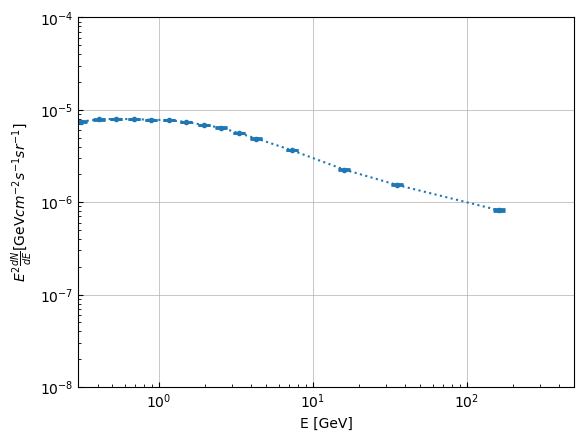

In [28]:
plt.style.use('default')
ax=plt.subplot()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

fitted=fitted_params#fitted_params
fitted_errors=np.zeros(17*5)#fitted_params_std
sr=0.214411*2
#sr=0.4776

ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')




ax.errorbar(E, fitted[0:17]*(pion+bremss)*(E**2)/(delta_E*sr), yerr=fitted_errors[0:17]*(pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
ax.errorbar(E, fitted[17:34]*(ics)*(E**2)/(delta_E*sr), yerr=fitted_errors[17:34]*(ics)*(E**2)/(delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

ax.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), linestyle='solid', label='pion+bremss', color='red')
ax.plot(E, (ics)*(E**2)/(delta_E*sr), linestyle='solid', label='ics', color='blue')



ax.errorbar(E,  fitted[34:51]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[34:51]*GCE)**2)*(E**2)/(delta_E*sr), alpha=0.5, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



ax.errorbar(E, fitted[51:68]*(bubble)*(E**2)/(delta_E*sr),yerr=fitted_errors[51:68]*(bubble)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')

ax.errorbar(E, fitted[68:85]*(isotropic)*(E**2)/(delta_E*sr),yerr=fitted_errors[68:85]*(isotropic)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')
summed = fitted[0:17]*(pion+bremss) + fitted[17:34]*(ics) + fitted[34:51]*(GCE) + fitted[51:68]*(bubble) + fitted[68:85]*(isotropic)

ax.plot(E, (E**2)*summed/(delta_E*sr), label='summed')

ax.text(2, 0.00005, f'roi={roi}', fontsize=12, color='red',
     bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.5'))

plt.show()

In [29]:
E

array([  0.3133289 ,   0.40699878,   0.52895368,   0.68756963,
         0.89424827,   1.16034479,   1.50678468,   1.96285509,
         2.55311571,   3.31659468,   4.30810856,   7.28203256,
        15.99875002,  35.0717842 , 161.09003423])